# Burn Scar Fine-Tuning with granite-geospatial-uki

Fine-tune an 8-band (Sentinel-1 + Sentinel-2) foundation model for binary burn scar segmentation.
Evaluated on Australian Black Summer fire events.

**Milestones:**
1. Dataset downloaded and verified
2. Australian events identified in test set
3. Phase 1 training (frozen backbone)
4. Phase 2 training (full fine-tuning)
5. Evaluation on Australian east-coast fires

In [ ]:
%load_ext autoreload
%autoreload 2

import logging

# === Configuration ===
import os
os.environ['AWS_NO_SIGN_REQUEST'] = 'YES'
from pathlib import Path

DATA_ROOT = Path("data/ImpactMesh-Fire")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# === Subset control ===
# Which split to use for training. Set to "val" if train S2L2A is not downloaded yet.
TRAIN_SPLIT = "val"

# Limit training samples for quick iteration. Set to None for full dataset.
MAX_TRAIN_SAMPLES = 500

# Training hyperparameters
PHASE1_EPOCHS = 20
PHASE1_BS = 16
PHASE1_LR = 1e-3

PHASE2_EPOCHS = 10
PHASE2_BS = 8
PHASE2_LR = 1e-4

# Feature flags
RUN_DEEP_DIVE = True  # Detailed Black Summer analysis

# Verify environment
assert (DATA_ROOT / "split").exists(), f"Data not found at {DATA_ROOT}. Run: bash setup.sh"
import torch
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
print(f"Training split: {TRAIN_SPLIT}, max samples: {MAX_TRAIN_SAMPLES or 'ALL'}")


GPU available: True
Device: NVIDIA L4
Training split: val, max samples: 500


> **Quick-start tip:**  MAX_TRAIN_SAMPLES above controls how much training data is used. Set it to  for a fast pipeline test (~10 minutes), or  to train on the full dataset (~2-3 hours per phase). The test/evaluation set is always used in full regardless of this setting.

## Milestone 1: Dataset Downloaded and Verified

Verify that S1RTC, S2L2A, and MASK modalities are extracted with matching sample counts across splits.

In [2]:
from modules.data import get_split_samples, ImpactMeshFireDataset
from modules.visualisation import display_sample

train_samples = get_split_samples(DATA_ROOT, TRAIN_SPLIT)
val_samples = get_split_samples(DATA_ROOT, "val")
test_samples = get_split_samples(DATA_ROOT, "test")

print(f"Train ({TRAIN_SPLIT}): {len(train_samples)} samples")
print(f"Val:   {len(val_samples)} samples")
print(f"Test:  {len(test_samples)} samples")


Train (val): 2372 samples
Val:   2372 samples
Test:  3772 samples


Available samples: 2372 / 2372


/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)


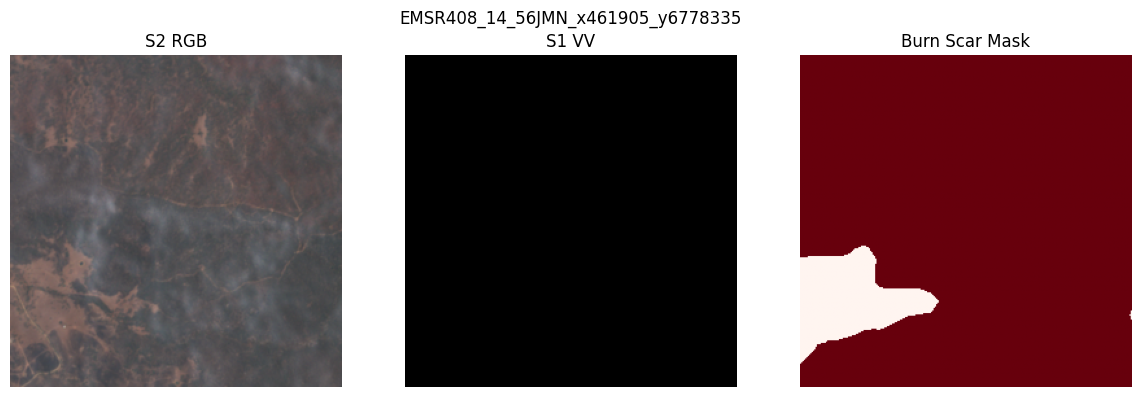

In [3]:
# Visual check: display a random sample (only uses data files present on disk)
import random
ds = ImpactMeshFireDataset(str(DATA_ROOT), split=TRAIN_SPLIT)
print(f"Available samples: {len(ds)} / {len(get_split_samples(DATA_ROOT, TRAIN_SPLIT))}")
assert len(ds) > 0, "No complete samples found on disk. Re-run: bash setup.sh"
idx = random.randint(0, len(ds) - 1)
sample = ds[idx]
display_sample(sample["image"].numpy(), sample["mask"].numpy(), ds.samples[idx])


## Milestone 2: Australian Events Identified in Test Set

Confirm that EMSR408 (Black Summer) samples are present in the test split.

In [4]:
from modules.data import identify_australian_events

au_test = identify_australian_events(test_samples)
au_val = identify_australian_events(val_samples)
print(f"Australian test samples (EMSR408): {len(au_test)}")
print(f"Australian val samples (EMSR408):  {len(au_val)}")

if len(au_test) < 50:
    print("WARNING: Fewer than 50 AU test samples. Evaluation may be unreliable.")
else:
    print("✓ Sufficient Australian samples for evaluation.")


Australian test samples (EMSR408): 400
Australian val samples (EMSR408):  300
✓ Sufficient Australian samples for evaluation.


## Milestone 3: Phase 1 Training (Frozen Backbone)

Train the decoder while keeping the granite-geospatial-uki backbone frozen.

In [5]:
from torch.utils.data import DataLoader
from torch.amp import GradScaler
from modules.model import GraniteUKIBurnScar
from modules.train import train_epoch, val_epoch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
model = GraniteUKIBurnScar(num_classes=2, freeze_backbone=True).to(device)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {n_params:,} total params, {n_trainable:,} trainable")

# Data
train_ds = ImpactMeshFireDataset(str(DATA_ROOT), split=TRAIN_SPLIT)
if MAX_TRAIN_SAMPLES:
    import random
    subset = random.sample(range(len(train_ds)), min(MAX_TRAIN_SAMPLES, len(train_ds)))
    train_ds = torch.utils.data.Subset(train_ds, subset)
    print(f"Using {len(train_ds)} training samples (subset)")
else:
    print(f"Using {len(train_ds)} training samples (full)")

val_ds = ImpactMeshFireDataset(str(DATA_ROOT), split="val")
train_loader = DataLoader(train_ds, batch_size=PHASE1_BS, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=PHASE1_BS, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

# Optimizer
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS, eta_min=1e-6)
scaler = GradScaler("cuda")

# Training loop
history_p1 = []
best_iou = 0.0
for epoch in range(PHASE1_EPOCHS):
    train_m = train_epoch(model, train_loader, optimizer, scaler, device)
    val_m = val_epoch(model, val_loader, device)
    scheduler.step()
    history_p1.append({"train": train_m, "val": val_m})
    print(f"[{epoch+1}/{PHASE1_EPOCHS}] loss={train_m['loss']:.4f} val_iou={val_m['iou']:.4f}", flush=True)
    if val_m["iou"] > best_iou:
        best_iou = val_m["iou"]
        torch.save(model.state_dict(), OUTPUT_DIR / "best_phase1.pt")

print(f"Phase 1 complete. Best val IoU: {best_iou:.4f}")


2026-05-28 03:47:31,660 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-granite/granite-geospatial-uki/resolve/main/granite_geospatial_uki.pt "HTTP/1.1 302 Found"
2026-05-28 03:47:31,661 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Model: 88,769,986 total params, 2,139,586 trainable
Using 500 training samples (subset)


/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)


[1/20] loss=0.5949 val_iou=0.3087
[2/20] loss=0.5016 val_iou=0.3420
[3/20] loss=0.4917 val_iou=0.3434
[4/20] loss=0.4602 val_iou=0.3284
[5/20] loss=0.4461 val_iou=0.3654
[6/20] loss=0.4307 val_iou=0.3851
[7/20] loss=0.4300 val_iou=0.3817
[8/20] loss=0.4437 val_iou=0.3755
[9/20] loss=0.4444 val_iou=0.3871
[10/20] loss=0.4144 val_iou=0.3867
[11/20] loss=0.4394 val_iou=0.3977
[12/20] loss=0.4068 val_iou=0.3908
[13/20] loss=0.4037 val_iou=0.3976
[14/20] loss=0.3939 val_iou=0.3896
[15/20] loss=0.4076 val_iou=0.4037
[16/20] loss=0.3979 val_iou=0.4001
[17/20] loss=0.3894 val_iou=0.4034
[18/20] loss=0.3909 val_iou=0.4070
[19/20] loss=0.3912 val_iou=0.4053
[20/20] loss=0.3838 val_iou=0.4069
Phase 1 complete. Best val IoU: 0.4070


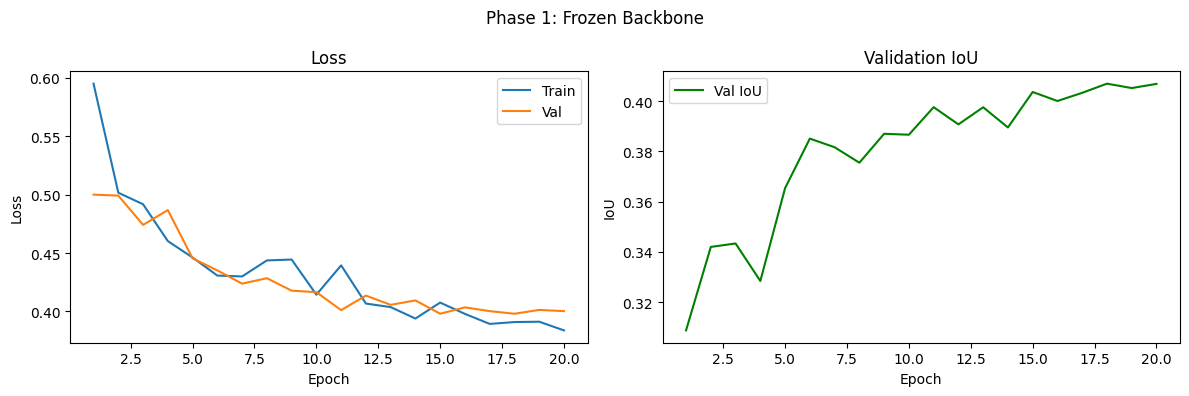

In [6]:
from modules.visualisation import plot_training_curves
plot_training_curves(history_p1, title="Phase 1: Frozen Backbone")


## Milestone 4: Phase 2 Training (Full Fine-Tuning)

Unfreeze the backbone and continue training at a lower learning rate.

In [7]:
# Unfreeze backbone
for p in model.backbone.parameters():
    p.requires_grad = True

# Differential LR
optimizer2 = torch.optim.AdamW([
    {"params": model.backbone.parameters(), "lr": PHASE2_LR * 0.1},
    {"params": model.decoder.parameters(), "lr": PHASE2_LR},
], weight_decay=1e-4)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=PHASE2_EPOCHS, eta_min=1e-6)
scaler2 = GradScaler("cuda")

# Smaller batch for memory
train_loader2 = DataLoader(train_ds, batch_size=PHASE2_BS, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader2 = DataLoader(val_ds, batch_size=PHASE2_BS, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

history_p2 = []
best_iou_p2 = best_iou
for epoch in range(PHASE2_EPOCHS):
    train_m = train_epoch(model, train_loader2, optimizer2, scaler2, device)
    val_m = val_epoch(model, val_loader2, device)
    scheduler2.step()
    history_p2.append({"train": train_m, "val": val_m})
    print(f"[{epoch+1}/{PHASE2_EPOCHS}] loss={train_m["loss"]:.4f} val_iou={val_m["iou"]:.4f}", flush=True)
    if val_m["iou"] > best_iou_p2:
        best_iou_p2 = val_m["iou"]
        torch.save(model.state_dict(), OUTPUT_DIR / "best_phase2.pt")

print(f"Phase 2 complete. Best val IoU: {best_iou_p2:.4f}")


/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)


[1/10] loss=0.4468 val_iou=0.3773
[2/10] loss=0.4396 val_iou=0.3495
[3/10] loss=0.4387 val_iou=0.3717
[4/10] loss=0.4213 val_iou=0.3699
[5/10] loss=0.4052 val_iou=0.3818
[6/10] loss=0.4144 val_iou=0.3952
[7/10] loss=0.4014 val_iou=0.3783
[8/10] loss=0.3875 val_iou=0.3784
[9/10] loss=0.4070 val_iou=0.3953
[10/10] loss=0.3963 val_iou=0.3938
Phase 2 complete. Best val IoU: 0.4070


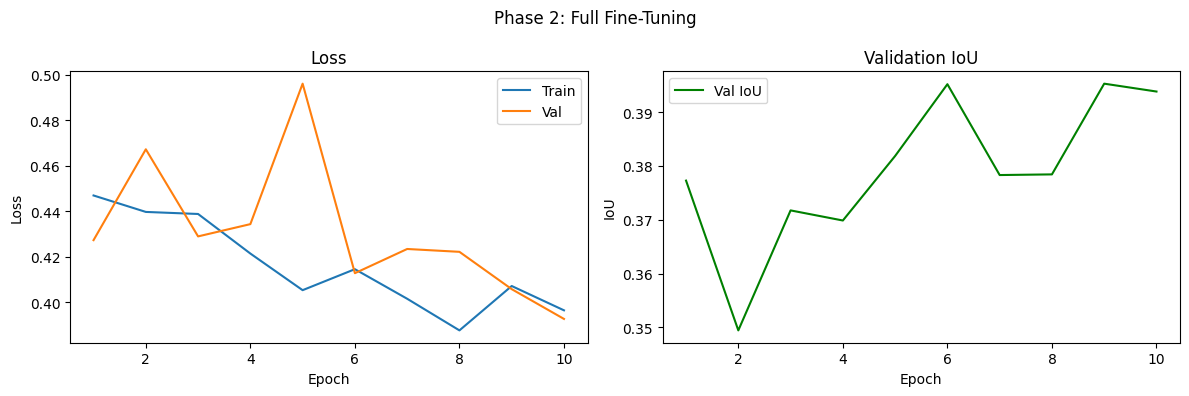

In [8]:
plot_training_curves(history_p2, title="Phase 2: Full Fine-Tuning")


In [10]:
torch.save(model.state_dict(), OUTPUT_DIR / "best_phase2.pt")

## Milestone 5: Evaluation on Australian East-Coast Fires

Evaluate IoU on the full test set and separately on Australian (EMSR408) samples.

In [11]:
from modules.train import compute_iou, dice_bce_loss
from modules.visualisation import plot_prediction_panels

# Load best model
model.load_state_dict(torch.load(OUTPUT_DIR / "best_phase2.pt", map_location=device))
model.eval()

# Full test evaluation
test_ds = ImpactMeshFireDataset(str(DATA_ROOT), split="test")
test_loader = DataLoader(test_ds, batch_size=PHASE2_BS, shuffle=False, num_workers=4)
test_m = val_epoch(model, test_loader, device)
print(f"Full test set — IoU: {test_m["iou"]:.4f}, Loss: {test_m["loss"]:.4f}")

# Australian subset
if au_test:
    au_ds = ImpactMeshFireDataset(str(DATA_ROOT), split="test", samples=au_test)
    au_loader = DataLoader(au_ds, batch_size=PHASE2_BS, shuffle=False, num_workers=4)
    au_m = val_epoch(model, au_loader, device)
    print(f"Australian test  — IoU: {au_m["iou"]:.4f}, Loss: {au_m["loss"]:.4f}")


/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)
/home/jovyan/kiro-foundation-model/modules/data.py:39: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(arr)


Full test set — IoU: 0.3477, Loss: 0.5338
Australian test  — IoU: 0.1364, Loss: 1.2369


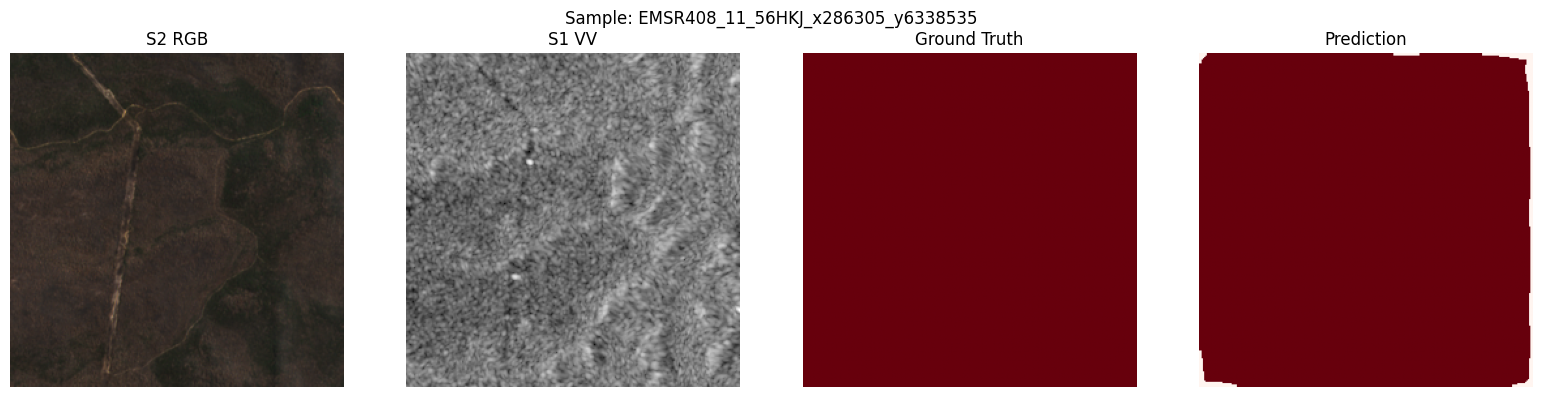

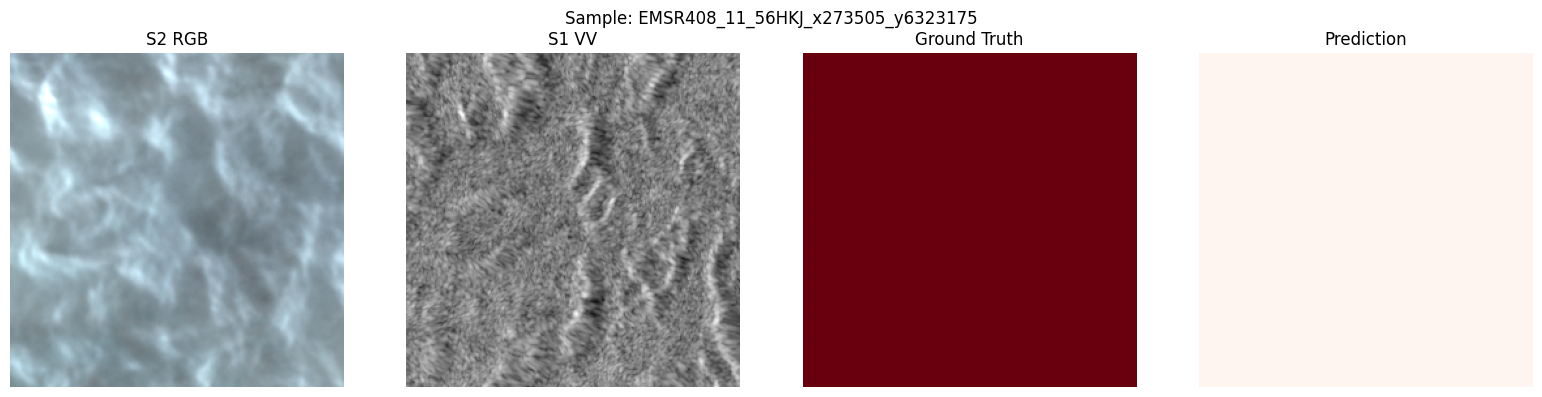

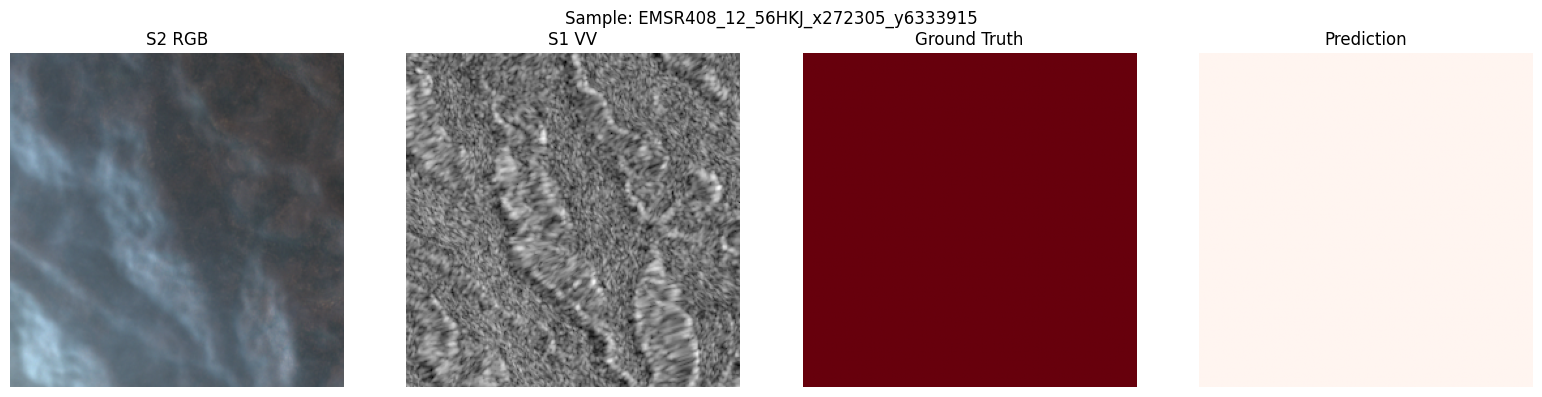

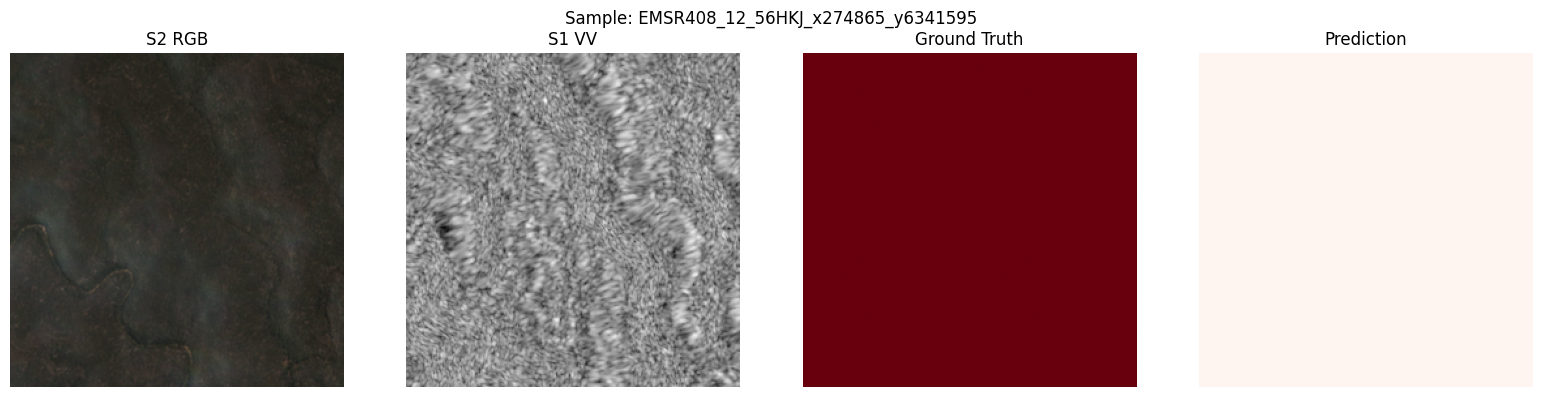

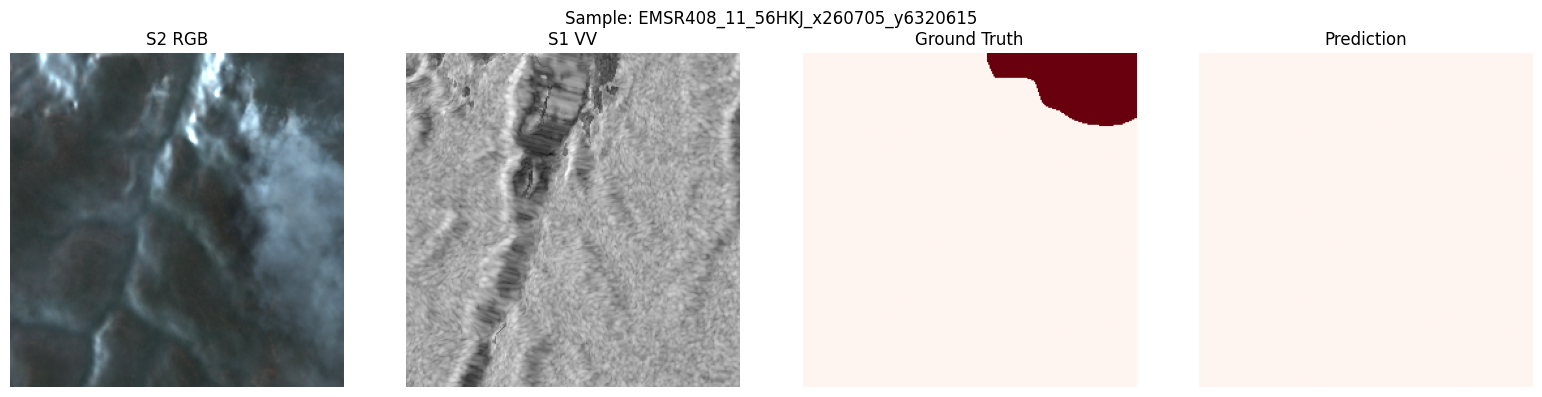

In [12]:
# Visual deep-dive: Black Summer predictions
if RUN_DEEP_DIVE and au_test:
    au_ds = ImpactMeshFireDataset(str(DATA_ROOT), split="test", samples=au_test[:5])
    for i in range(min(5, len(au_ds))):
        sample = au_ds[i]
        img = sample["image"].unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img).argmax(dim=1).cpu().numpy()[0]
        plot_prediction_panels(
            sample["image"].numpy(),
            sample["mask"].numpy(),
            pred,
            sample_id=au_test[i]
        )


## Summary

Results and next steps will be filled after training completes.